In [1]:
import pandas as pd
from sklearn import decomposition
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from sklearn.cluster import KMeans
import numpy as np
from plotnine import *
import warnings
from matplotlib import *


In [2]:
warnings.filterwarnings("ignore", message="Could not find the number of physical cores")


In [3]:
# import Excel sheet
data = pd.read_csv("eeg-eye-state.csv")

In [4]:
# drop categorical column
data = data.drop(columns=["eyeDetection"])

In [5]:
# visualize data 
data.head()

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46


In [6]:
# define variable that will standardize a series
def standardize(series):
    return (series - series.mean()) / series.std()

In [7]:
# standardize data set
data_standard = data.apply(standardize)
data_standard.head() # visualize to ensure all standard

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4
0,0.002934,-0.011704,0.567380,-0.003208,0.245228,-0.019787,-0.002930,0.852539,0.001509,0.187743,0.233502,0.030744,0.017126,-0.003834
1,0.001084,-0.112048,0.671368,-0.003111,0.008893,-0.019609,-0.002817,0.782214,-0.003771,-0.122105,0.138493,0.006192,0.014577,-0.005489
2,0.002316,-0.067427,0.705806,-0.001636,-0.138781,-0.020662,-0.002930,0.484870,-0.005213,-0.243521,0.111499,0.067813,0.011184,-0.004618
3,0.002730,0.044019,0.728989,-0.001734,0.053224,-0.021014,-0.002817,0.502280,-0.000649,0.106799,0.220005,0.203571,0.014155,-0.003399
4,0.001698,0.044019,0.636705,-0.002620,0.171247,-0.019609,-0.003152,0.397134,-0.003771,0.335966,0.274258,0.216088,0.014577,-0.003051


In [8]:
# no need to do embeddings like previous problem set because csv is already numbers
pca_raw = decomposition.PCA() # performed on all components
pca = pd.DataFrame(
    pca_raw.fit_transform(data_standard)
)
pca = pca.rename(columns={0: 'PCA0', 1: 'PCA1'})

In [9]:
pca.head()

,PCA0,PCA1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.417793,-0.013065,0.288558,0.567410,0.435357,-0.120046,0.521994,0.151257,-0.224877,-0.264516,0.022224,0.006771,0.000246,0.011734
1,0.364204,-0.076547,0.326739,0.315702,0.255801,-0.220059,0.513467,0.313599,-0.435848,-0.313905,0.025137,0.004363,0.001548,0.009022
2,0.327206,-0.136215,0.350186,0.125139,0.103205,-0.138291,0.286483,0.406929,-0.452919,-0.295112,0.018836,0.002422,0.000851,0.008964
3,0.420266,-0.122798,0.395207,0.405395,0.295541,-0.017629,0.206967,0.366122,-0.224588,-0.250669,0.014771,0.001648,-0.000128,0.011608
4,0.404974,-0.093111,0.330075,0.481530,0.421499,0.033727,0.096210,0.280887,-0.027145,-0.219816,0.012952,0.003604,0.000074,0.010690


In [10]:
print(pca.columns.tolist())


['PCA0', 'PCA1', 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]


In [11]:
# plot PCA0 vs PCA1

fig = make_subplots(rows=1, cols=1)

fig.add_trace(
    go.Scatter(
        x=pca['PCA0'],
        y=pca['PCA1'],
        mode='markers',
        marker=dict(size=6, opacity=0.7),
        name="PCA Points"
    ),
    row=1, col=1
)

fig.update_layout(
    title="EEG Eye State - PC0 vs PC1",
    xaxis_title="PC0",
    yaxis_title="PC1",
    template="plotly_white"
)

fig.write_image('Original_PCA.png')
fig.show()


In [12]:
# zoom in near origin
fig = make_subplots(rows=1, cols=1)

fig.add_trace(
    go.Scatter(
        x=pca['PCA0'],
        y=pca['PCA1'],
        mode='markers',
        marker=dict(size=6, opacity=0.7),
        name="PCA Points"
    ),
    row=1, col=1
)

fig.update_layout(
    title="EEG Eye State - PC0 vs PC1",
    xaxis_title="PC0",
    yaxis_title="PC1",
    template="plotly_white",
    xaxis_range=[-2, 4],
    yaxis_range=[-1.5,1.5],
    width=800,
    height=800
)

fig.write_image('Zoom_PCA.png')
fig.show()


In [39]:
# implement k-means clustering with sklearn library. 
# k=7; init=random
# https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

kmeans = KMeans(n_clusters=7, init="random", random_state=1).fit(data_standard)

In [40]:
centers_df =  (
    pca.groupby('cluster')[['PCA0','PCA1']]
    .mean()
    .reset_index()

)

In [41]:
centers_df

,cluster,PCA0,PCA1
0,0,-0.140614,-0.016051
1,1,135.115917,-8.777743
2,2,0.392107,0.112640
3,3,0.433794,-0.193032
4,4,-0.472821,-0.086201
5,5,-32.723770,138.169825
6,6,2.061444,0.398914


In [42]:
# # Asked ChatGPT how to make scatterplot of kmeans, order the legend and add center of clusters
# add cluster to PCA dataframe
# makes string so can be plotted as discrete and not continuous

pca["cluster"] = kmeans.labels_
pca["cluster"] = pca["cluster"].astype(str) # makes string so can be plotted as discrete and not continuous


cluster_order = [str(i) for i in range(7)]  # Specifying order of clusters for legend


In [43]:
# adds center 
# asked ChatGPT how to make it plottable
centers_pca = pca_raw.transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_pca[:, :2], columns=['PCA0', 'PCA1'])

c:\Users\carol\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but PCA was fitted with feature names



In [44]:
centers_df

,PCA0,PCA1
0,-0.475204,-0.087102
1,0.434803,-0.192544
2,-0.144944,-0.016818
3,-32.723770,138.169825
4,135.115917,-8.777743
5,2.061444,0.398914
6,0.388312,0.111846


In [ ]:
# testing to determine what clusters are being plotted in viewing plane
from scipy.spatial.distance import pdist, squareform
dists=squareform(pdist(centers_df[['PCA0','PCA1']]))
np.set_printoptions(precision=4, suppress=True)
print(dists)

[[  0.       0.9161   0.3377 141.9681 135.8693   2.5828   0.8861]
 [  0.9161   0.       0.6058 142.2801 134.9545   1.7308   0.3079]
 [  0.3377   0.6058   0.     141.9751 135.5443   2.2452   0.5486]
 [141.9681 142.2801 141.9751   0.     223.0779 142.0945 141.9733]
 [135.8693 134.9545 135.5443 223.0779   0.     133.3706 135.0206]
 [  2.5828   1.7308   2.2452 142.0945 133.3706   0.       1.6976]
 [  0.8861   0.3079   0.5486 141.9733 135.0206   1.6976   0.    ]]


In [46]:
pca.head()

,PCA0,PCA1,2,3,4,5,6,7,8,9,10,11,12,13,cluster
0,0.417793,-0.013065,0.288558,0.567410,0.435357,-0.120046,0.521994,0.151257,-0.224877,-0.264516,0.022224,0.006771,0.000246,0.011734,6
1,0.364204,-0.076547,0.326739,0.315702,0.255801,-0.220059,0.513467,0.313599,-0.435848,-0.313905,0.025137,0.004363,0.001548,0.009022,6
2,0.327206,-0.136215,0.350186,0.125139,0.103205,-0.138291,0.286483,0.406929,-0.452919,-0.295112,0.018836,0.002422,0.000851,0.008964,2
3,0.420266,-0.122798,0.395207,0.405395,0.295541,-0.017629,0.206967,0.366122,-0.224588,-0.250669,0.014771,0.001648,-0.000128,0.011608,6
4,0.404974,-0.093111,0.330075,0.481530,0.421499,0.033727,0.096210,0.280887,-0.027145,-0.219816,0.012952,0.003604,0.000074,0.010690,6


In [ ]:

# seeing if any pca centers are being dropped due to na
pca.isna().sum()

PCA0       0
PCA1       0
2          0
3          0
4          0
5          0
6          0
7          0
8          0
9          0
10         0
11         0
12         0
13         0
cluster    0
dtype: int64

In [48]:
import matplotlib.pyplot as plt


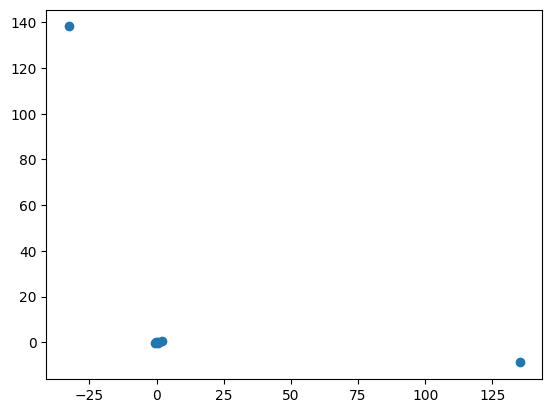

In [75]:
# two centers outside df
plt.scatter(centers_df["PCA0"], centers_df["PCA1"])
plt.savefig('zoomed_out_centers.png')


c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning:

Saving 6.4 x 4.8 in image.

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning:

Filename: x_centers.png

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning:

geom_point : Removed 4 rows containing missing values.

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning:

geom_point : Removed 2 rows containing missing values.

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning:

geom_point : Removed 4 rows containing missing values.

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning:

geom_point : Removed 2 rows containing missing values.



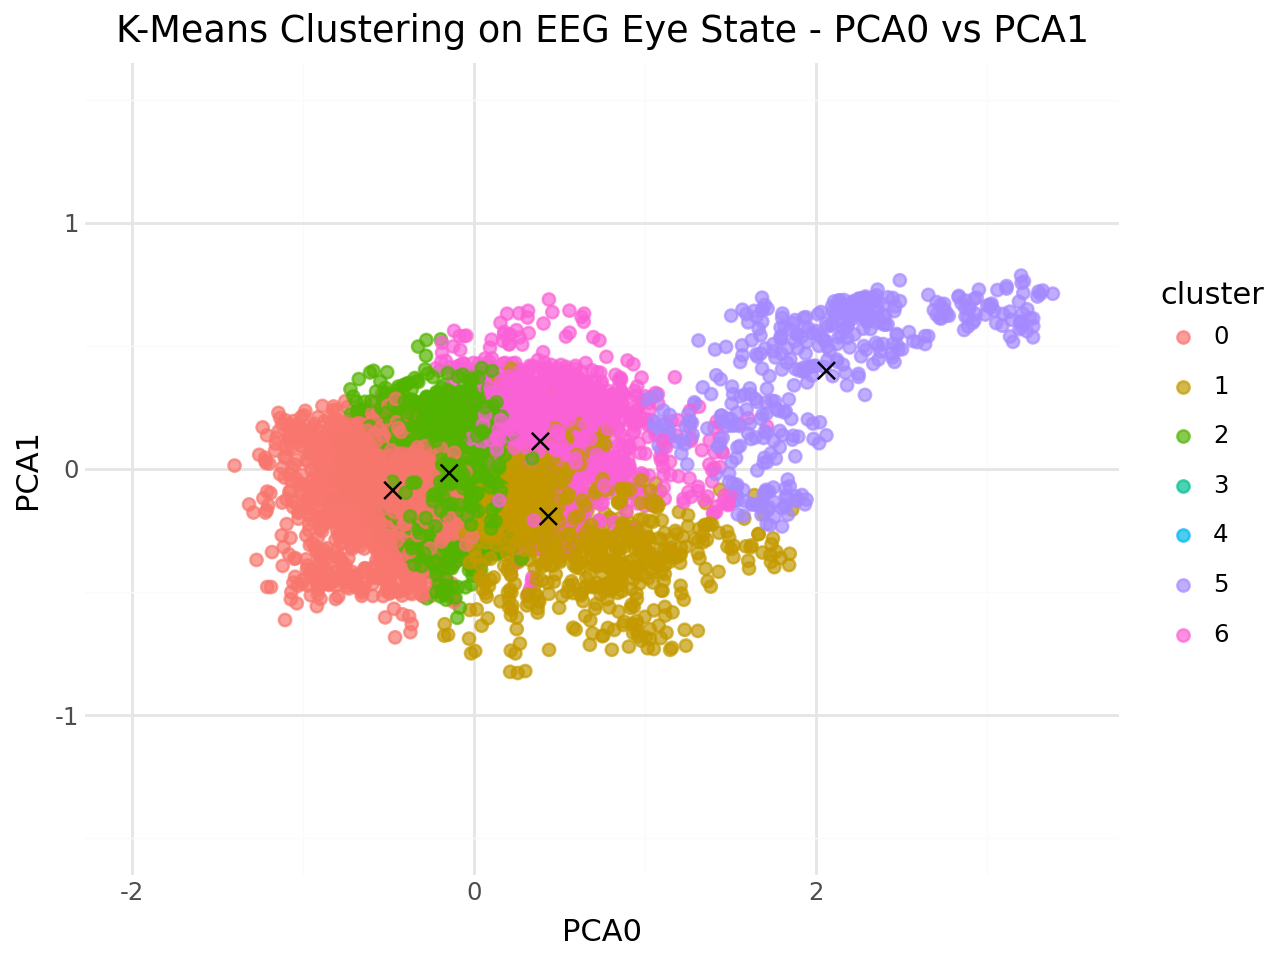

In [52]:
graph = (
    ggplot(pca, aes(x='PCA0', y='PCA1', color='cluster')) 
    + geom_point(size=2, alpha=0.7) 
    + geom_point(
        data=centers_df,
        mapping=aes(x='PCA0', y='PCA1'),
        shape='x', 
        size=3,  
        color='black' 
    ) 
    + labs(
    x='PCA0',
    y='PCA1',
    title = 'K-Means Clustering on EEG Eye State - PCA0 vs PCA1'
) + theme_minimal()
+ xlim(-2, 3.5)
+ ylim(-1.5, 1.5)
)

graph.save('x_centers.png')
graph


c:\Users\carol\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but PCA was fitted with feature names

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning:

Saving 6.4 x 4.8 in image.

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning:

Filename: x_centers_1.png

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning:

geom_point : Removed 4 rows containing missing values.

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning:

geom_point : Removed 2 rows containing missing values.

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning:

geom_point : Removed 4 rows containing missing values.

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning:

geom_point : Removed 2 rows containing missing values.



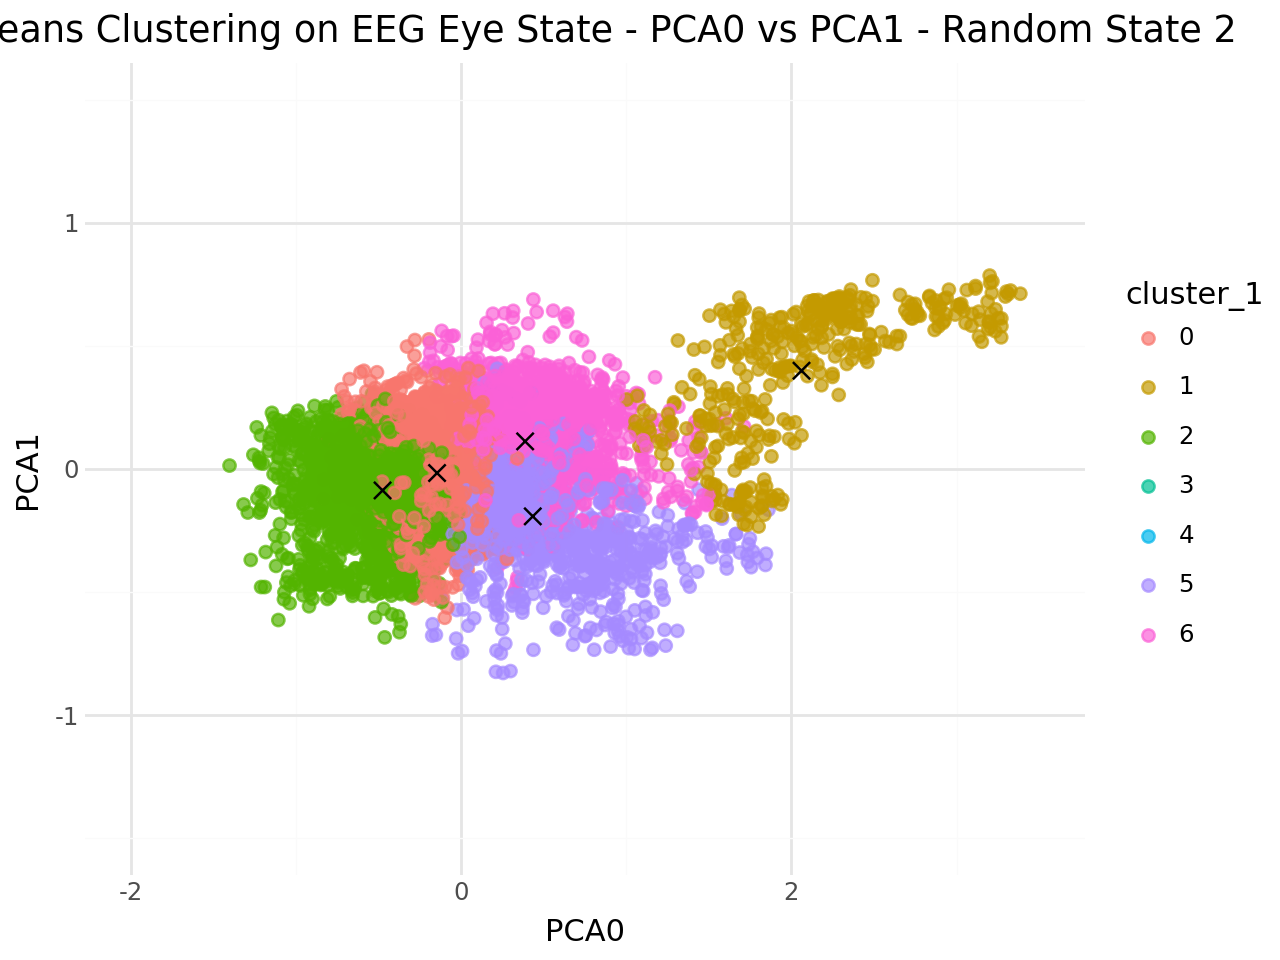

In [57]:
# implement kmeans multiple times

kmeans_1 = KMeans(n_clusters=7, init="random", random_state=2).fit(data_standard)

pca["cluster_1"] = kmeans_1.labels_
pca["cluster_1"] = pca["cluster_1"].astype(str) # makes string so can be plotted as discrete and not continuous


cluster_order_1 = [str(i) for i in range(7)]  # Specifying order of clusters for legend

centers_pca_1 = pca_raw.transform(kmeans_1.cluster_centers_)
centers_df_1 = pd.DataFrame(centers_pca_1[:, :2], columns=['PCA0', 'PCA1'])

graph = (
    ggplot(pca, aes(x='PCA0', y='PCA1', color='cluster_1')) 
    + geom_point(size=2, alpha=0.7) 
    + geom_point(
        data=centers_df_1,
        mapping=aes(x='PCA0', y='PCA1'),
        shape='x', 
        size=3,  
        color='black' 
    ) 
    + labs(
    x='PCA0',
    y='PCA1',
    title = 'K-Means Clustering on EEG Eye State - PCA0 vs PCA1 - Random State 2'
) + theme_minimal()
+ xlim(-2, 3.5)
+ ylim(-1.5, 1.5)
)

graph.save('x_centers_1.png')
graph

c:\Users\carol\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but PCA was fitted with feature names

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning:

Saving 6.4 x 4.8 in image.

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning:

Filename: x_centers_2.png

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning:

geom_point : Removed 4 rows containing missing values.

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning:

geom_point : Removed 2 rows containing missing values.

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning:

geom_point : Removed 4 rows containing missing values.

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning:

geom_point : Removed 2 rows containing missing values.



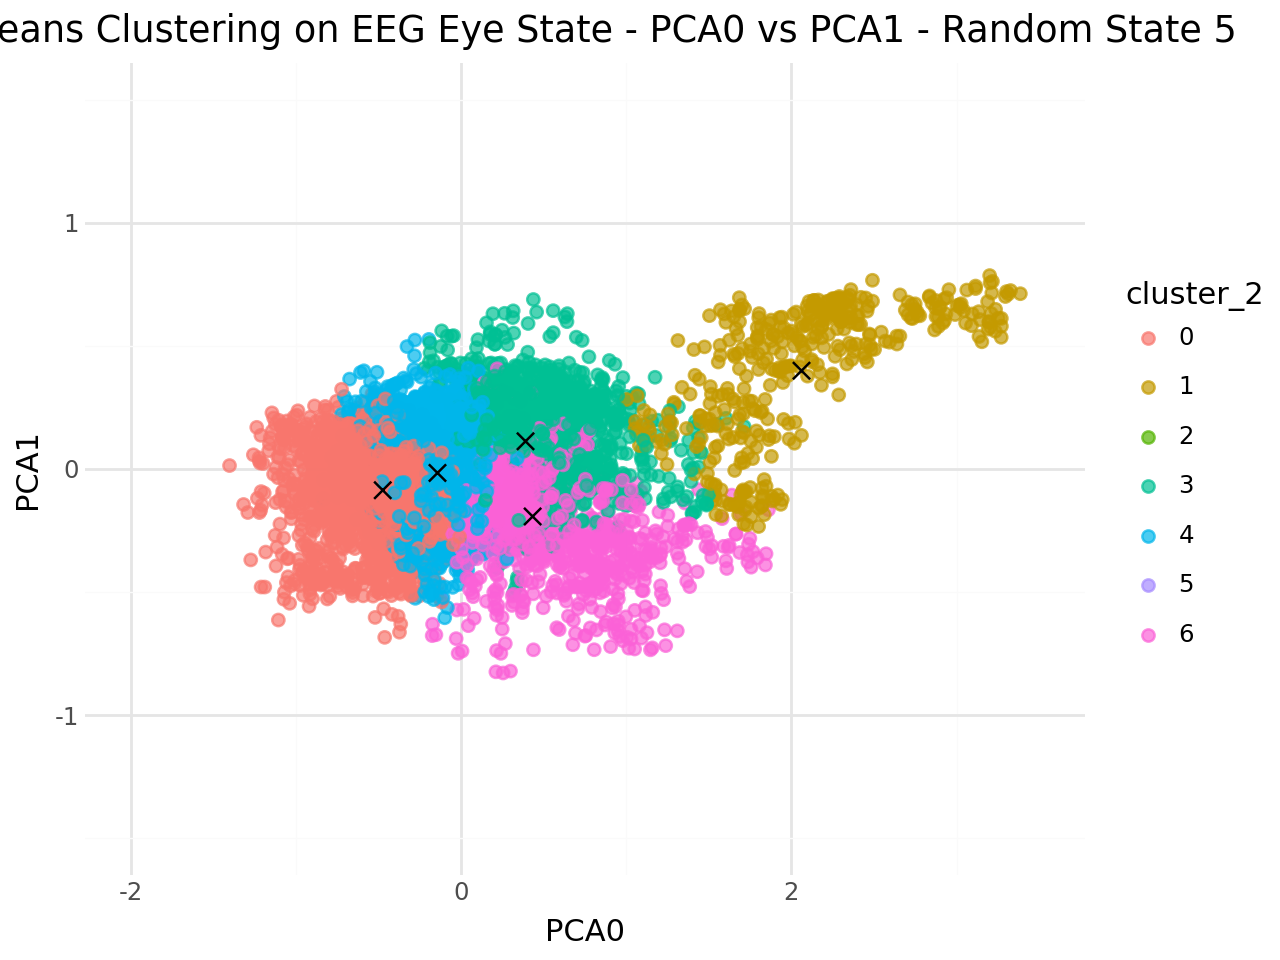

In [58]:
# implement kmeans multiple times

kmeans_2 = KMeans(n_clusters=7, init="random", random_state=5).fit(data_standard)

pca["cluster_2"] = kmeans_2.labels_
pca["cluster_2"] = pca["cluster_2"].astype(str) # makes string so can be plotted as discrete and not continuous


cluster_order_2 = [str(i) for i in range(7)]  # Specifying order of clusters for legend

centers_pca_2 = pca_raw.transform(kmeans_2.cluster_centers_)
centers_df_2 = pd.DataFrame(centers_pca_2[:, :2], columns=['PCA0', 'PCA1'])

graph = (
    ggplot(pca, aes(x='PCA0', y='PCA1', color='cluster_2')) 
    + geom_point(size=2, alpha=0.7) 
    + geom_point(
        data=centers_df_2,
        mapping=aes(x='PCA0', y='PCA1'),
        shape='x', 
        size=3,  
        color='black' 
    ) 
    + labs(
    x='PCA0',
    y='PCA1',
    title = 'K-Means Clustering on EEG Eye State - PCA0 vs PCA1 - Random State 5'
) + theme_minimal()
+ xlim(-2, 3.5)
+ ylim(-1.5, 1.5)
)

graph.save('x_centers_2.png')
graph

c:\Users\carol\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but PCA was fitted with feature names

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning:

Saving 6.4 x 4.8 in image.

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning:

Filename: x_centers_3.png

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning:

geom_point : Removed 4 rows containing missing values.

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning:

geom_point : Removed 4 rows containing missing values.



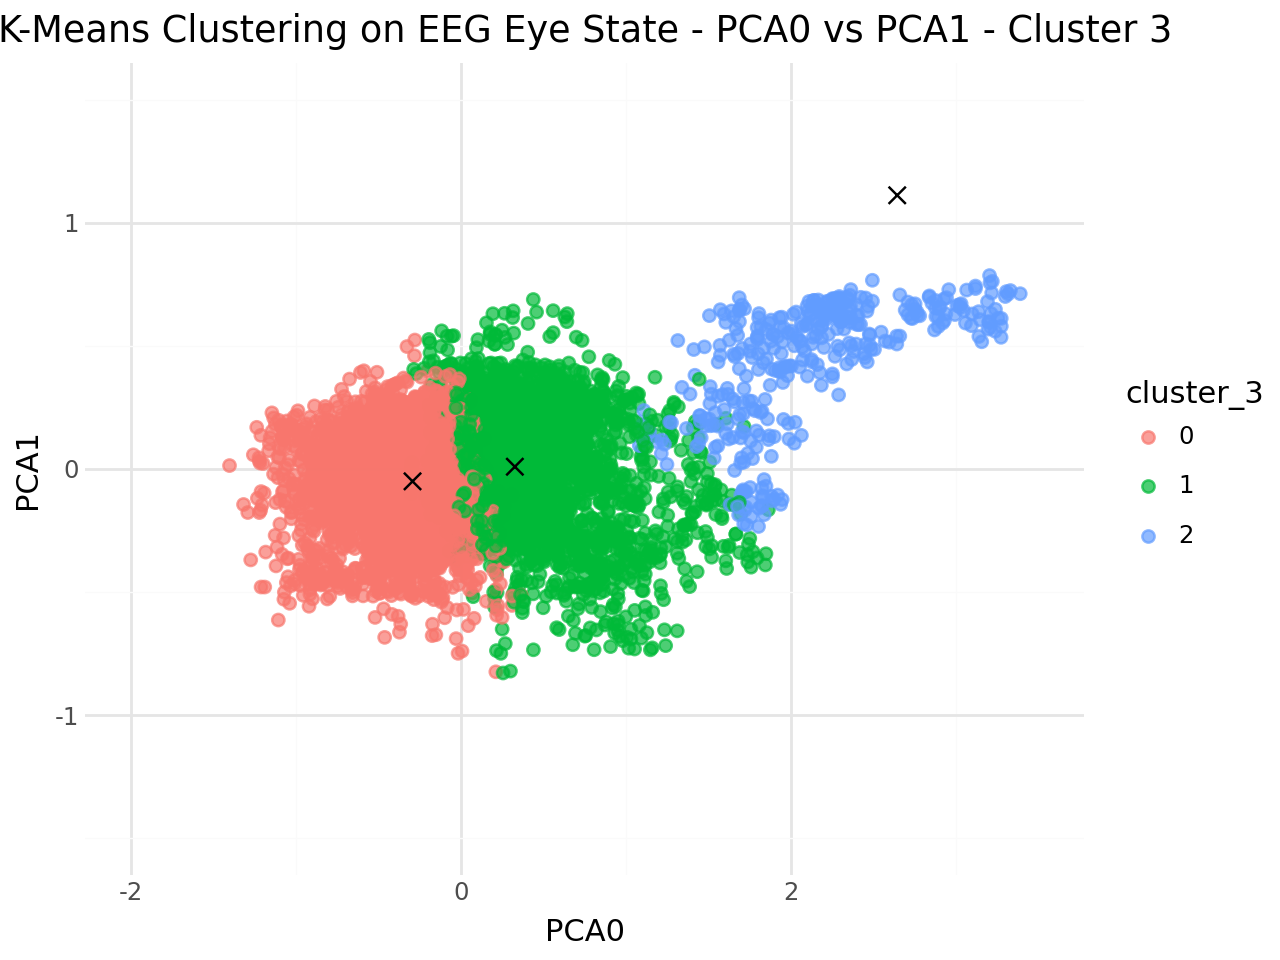

In [68]:
# implement kmeans multiple times

kmeans_3 = KMeans(n_clusters=3, init="random", random_state=0).fit(data_standard)

pca["cluster_3"] = kmeans_3.labels_ #labels_
pca["cluster_3"] = pca["cluster_3"].astype(str) # makes string so can be plotted as discrete and not continuous

cluster_order_3 = [str(i) for i in range(3)]  # Specifying order of clusters for legend

centers_pca_3 = pca_raw.transform(kmeans_3.cluster_centers_)
centers_df_3 = pd.DataFrame(centers_pca_3[:, :2], columns=['PCA0', 'PCA1'])

graph = (
    ggplot(pca, aes(x='PCA0', y='PCA1', color='cluster_3')) 
    + geom_point(size=2, alpha=0.7) 
    + geom_point(
        data=centers_df_3,
        mapping=aes(x='PCA0', y='PCA1'),
        shape='x', 
        size=3,  
        color='black' 
    ) 
    + labs(
    x='PCA0',
    y='PCA1',
    title = 'K-Means Clustering on EEG Eye State - PCA0 vs PCA1 - Cluster 3'
) + theme_minimal()
+ xlim(-2, 3.5)
+ ylim(-1.5, 1.5)
)

graph.save('x_centers_3.png')
graph

c:\Users\carol\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but PCA was fitted with feature names

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning:

Saving 6.4 x 4.8 in image.

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning:

Filename: x_centers_4.png

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning:

geom_point : Removed 4 rows containing missing values.

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning:

geom_point : Removed 3 rows containing missing values.

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning:

geom_point : Removed 4 rows containing missing values.

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning:

geom_point : Removed 3 rows containing missing values.



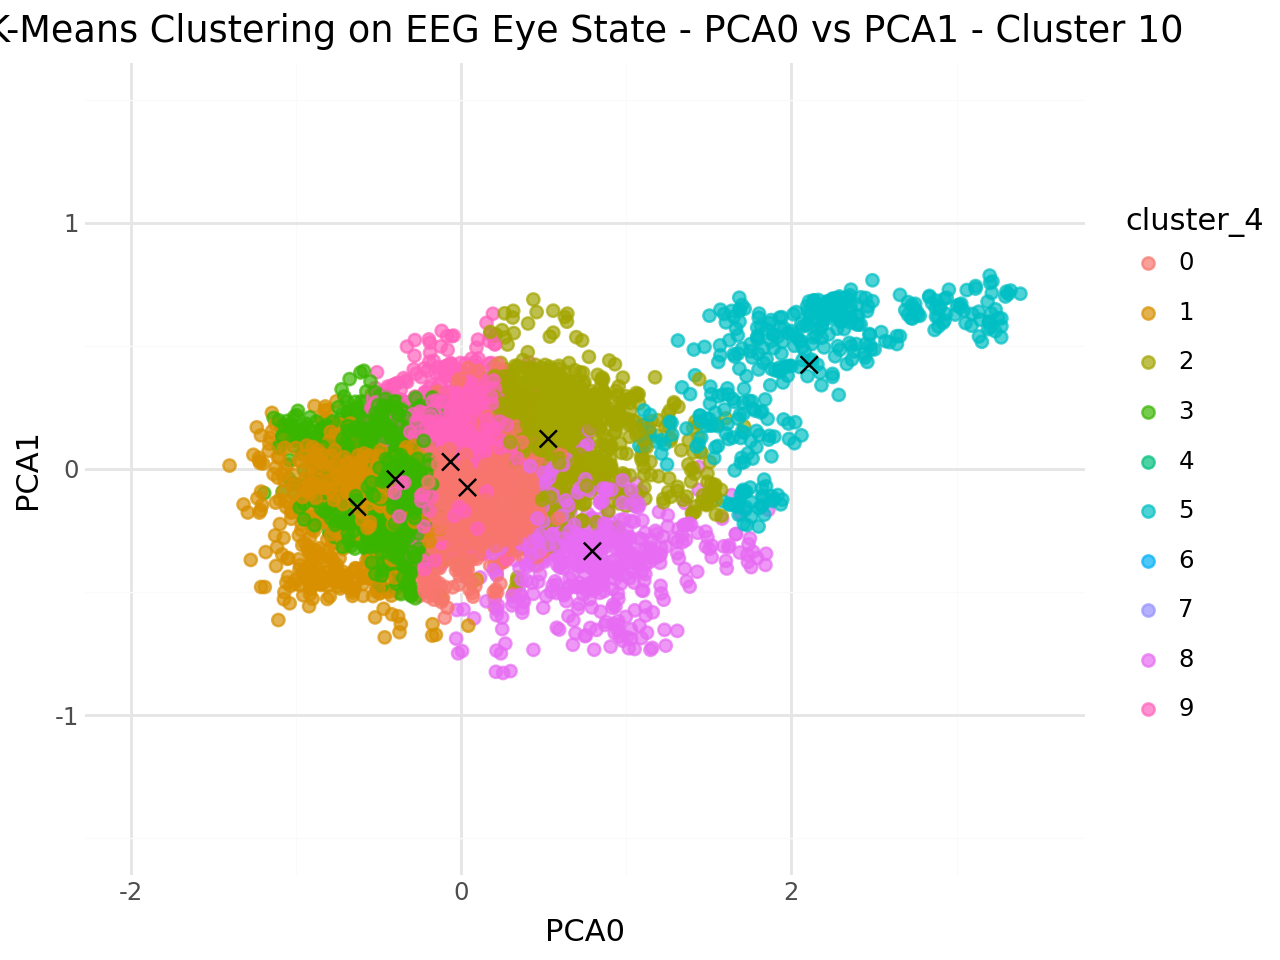

In [72]:
# implement kmeans multiple times

kmeans_4 = KMeans(n_clusters=10, init="random", random_state=0).fit(data_standard)

pca["cluster_4"] = kmeans_4.labels_ #labels_
pca["cluster_4"] = pca["cluster_4"].astype(str) # makes string so can be plotted as discrete and not continuous

cluster_order_4 = [str(i) for i in range(3)]  # Specifying order of clusters for legend

centers_pca_4 = pca_raw.transform(kmeans_4.cluster_centers_)
centers_df_4 = pd.DataFrame(centers_pca_4[:, :2], columns=['PCA0', 'PCA1'])

graph = (
    ggplot(pca, aes(x='PCA0', y='PCA1', color='cluster_4')) 
    + geom_point(size=2, alpha=0.7) 
    + geom_point(
        data=centers_df_4,
        mapping=aes(x='PCA0', y='PCA1'),
        shape='x', 
        size=3,  
        color='black' 
    ) 
    + labs(
    x='PCA0',
    y='PCA1',
    title = 'K-Means Clustering on EEG Eye State - PCA0 vs PCA1 - Cluster 10'
) + theme_minimal()
+ xlim(-2, 3.5)
+ ylim(-1.5, 1.5)
)

graph.save('x_centers_4.png')
graph

c:\Users\carol\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but PCA was fitted with feature names

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning:

Saving 6.4 x 4.8 in image.

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning:

Filename: x_centers_5.png



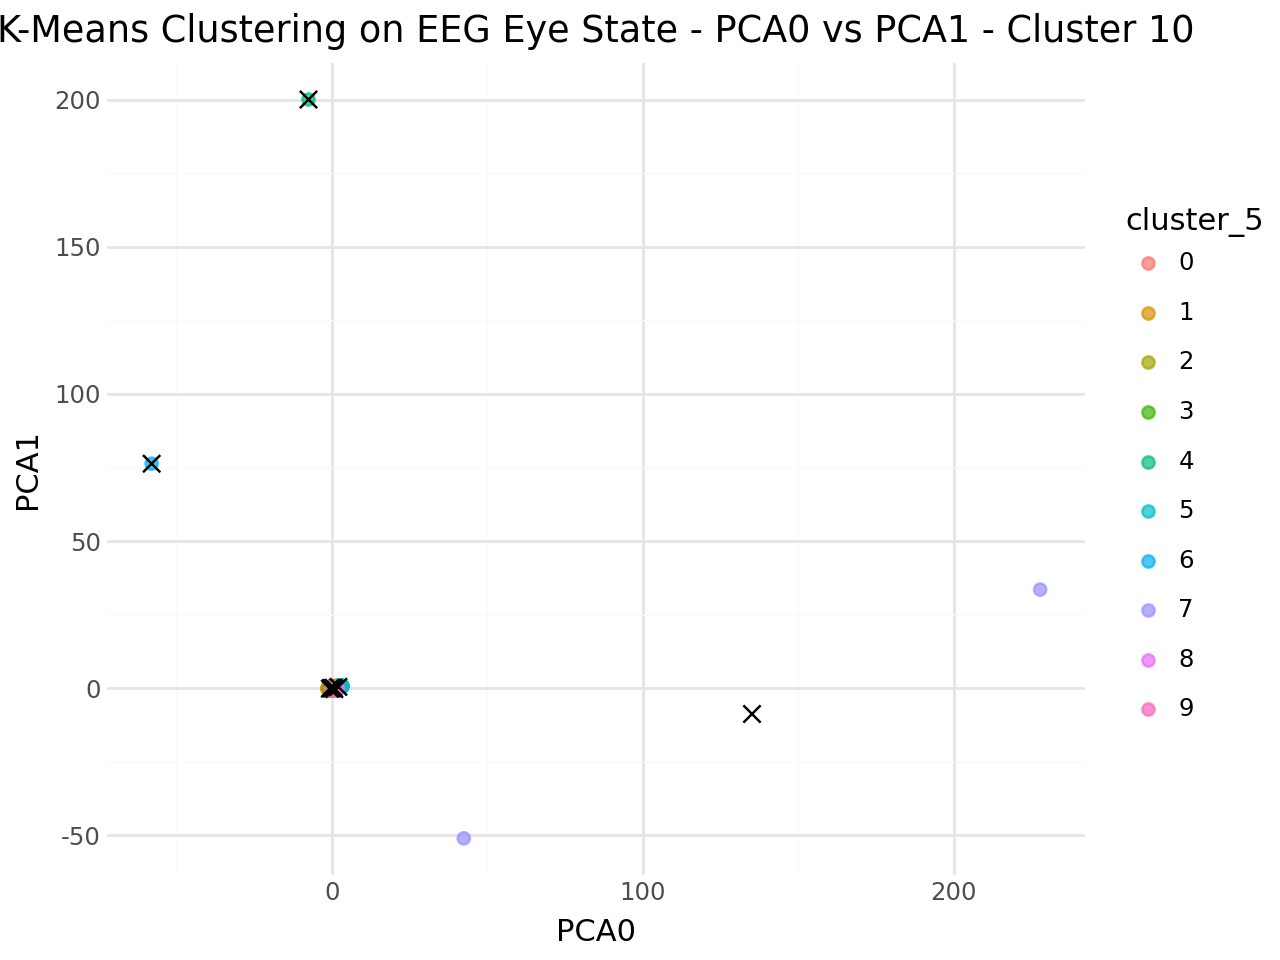

In [73]:
# implement kmeans multiple times

kmeans_5 = KMeans(n_clusters=10, init="random", random_state=0).fit(data_standard)

pca["cluster_5"] = kmeans_5.labels_ #labels_
pca["cluster_5"] = pca["cluster_5"].astype(str) # makes string so can be plotted as discrete and not continuous

cluster_order_5 = [str(i) for i in range(10)]  # Specifying order of clusters for legend

centers_pca_5 = pca_raw.transform(kmeans_5.cluster_centers_)
centers_df_5 = pd.DataFrame(centers_pca_5[:, :2], columns=['PCA0', 'PCA1'])

graph = (
    ggplot(pca, aes(x='PCA0', y='PCA1', color='cluster_5')) 
    + geom_point(size=2, alpha=0.7) 
    + geom_point(
        data=centers_df_5,
        mapping=aes(x='PCA0', y='PCA1'),
        shape='x', 
        size=3,  
        color='black' 
    ) 
    + labs(
    x='PCA0',
    y='PCA1',
    title = 'K-Means Clustering on EEG Eye State - PCA0 vs PCA1 - Cluster 10'
) + theme_minimal()
#+ xlim(-2, 3.5)
#+ ylim(-1.5, 1.5)
)

graph.save('x_centers_5.png')
graph